# Chapter 6 - Feature Engineering I

Feature engineering prepares raw data so that a machine learning model can learn
useful patterns from it. In this chapter we focus on three practical families of
techniques: encoding categorical features, scaling numerical features, and
transforming skewed numerical features.

In [ ]:
# Common imports used throughout the code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer, StandardScaler

sns.set_theme(style="whitegrid")

## Feature Engineering Techniques

Feature engineering means improving a dataset by creating, encoding, scaling, or
transforming features before modeling. The chapter introduces feature
construction, feature transformation, feature encoding, feature scaling, feature
selection, missing-value handling, and outlier handling.

## Feature Encoding

Machine learning algorithms need numerical inputs. Encoding converts categorical
values such as gender, education level, or review quality into numbers while
preserving the meaning needed by the model.

In [ ]:
# Load the customer data used for encoding examples.
customers_data_url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch06/customers.csv'

customers = pd.read_csv(customers_data_url)

# display first 5 rows of our customers data
print(customers.head())

   age  gender   review education purchased
0   30  Female  Average    School        No
1   68  Female     Poor        UG        No
2   70  Female     Good        PG        No
3   72  Female     Good        PG        No
4   16  Female  Average        UG        No


In [42]:
print("\nColumn types before encoding:")
print(customers.dtypes)


Column types before encoding:
age          int64
gender         str
review         str
education      str
purchased      str
dtype: object


### Ordinal Encoding

Ordinal encoding is used when categories have a natural order. In this dataset,
review has the order Poor < Average < Good, and education has the order School
< UG < PG. We show the original values first, then encode them.

In [43]:
# Before: inspect the ordered categorical columns in their original form.
encoding_df = customers.copy()

ordinal_columns = ["review", "education"]

print(encoding_df[ordinal_columns].head())

    review education
0  Average    School
1     Poor        UG
2     Good        PG
3     Good        PG
4  Average        UG


In [44]:
# Apply ordinal encoding with explicit category order.
ordinal_categories = [
    ["Poor", "Average", "Good"],
    ["School", "UG", "PG"],
]

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
encoding_df[ordinal_columns] = ordinal_encoder.fit_transform(encoding_df[ordinal_columns])

# After: the two ordered columns are now numeric but still preserve rank.
print(encoding_df[ordinal_columns].head())

   review  education
0     1.0        0.0
1     0.0        1.0
2     2.0        2.0
3     2.0        2.0
4     1.0        1.0


### One-Hot Encoding

One-hot encoding is used when categories do not have a meaningful order. Gender
is nominal here, so we create one indicator column per category instead of
assigning an artificial rank.

In [45]:
# Before: inspect the nominal column and its category counts.
print(customers[["gender"]].head())
print("\nGender counts:")
print(customers["gender"].value_counts())

   gender
0  Female
1  Female
2  Female
3  Female
4  Female

Gender counts:
gender
Female    29
Male      21
Name: count, dtype: int64


In [46]:
# Apply one-hot encoding to the gender column.
one_hot_encoder = OneHotEncoder(sparse_output=False, drop=None)
gender_encoded = one_hot_encoder.fit_transform(customers[["gender"]])
gender_encoded_df = pd.DataFrame(
    gender_encoded,
    columns=one_hot_encoder.get_feature_names_out(["gender"]),
    index=customers.index,
)

encoding_df = pd.concat([encoding_df.drop(columns=["gender"]), gender_encoded_df], axis=1)

# After: the original gender column is replaced by clear binary columns.
print(encoding_df[["age", "gender_Female", "gender_Male"]].head())

   age  gender_Female  gender_Male
0   30            1.0          0.0
1   68            1.0          0.0
2   70            1.0          0.0
3   72            1.0          0.0
4   16            1.0          0.0


### Label Encoding for the Target

Label encoding is commonly used for a target column with class labels. Here the
target purchased is converted into numbers so that it can be used by models.

In [47]:
# Before: inspect the target labels.
print(customers[["purchased"]].head())
print("\nTarget labels:")
print(customers["purchased"].value_counts())

  purchased
0        No
1        No
2        No
3        No
4        No

Target labels:
purchased
No     26
Yes    24
Name: count, dtype: int64


In [48]:
# Encode the target labels.
label_encoder = LabelEncoder()
encoding_df["purchased"] = label_encoder.fit_transform(customers["purchased"])

# After: show the label mapping and a small preview.
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_mapping)
print(encoding_df[["age", "purchased"]].head())

Label mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
   age  purchased
0   30          0
1   68          0
2   70          0
3   72          0
4   16          0


## Feature Scaling

Features can have very different numerical ranges. For example, age may be in
tens while salary may be in thousands. Scaling prevents large-magnitude features
from dominating algorithms that use gradients or distances.

### Standardization

Standardization, also called Z-score scaling, transforms features so that the
training data has mean 0 and standard deviation 1. We fit the scaler on the
training set only, then transform both train and test sets using the learned
training-set parameters.

In [ ]:
# Load the social network advertising data and keep the chapter's modeling columns.
ads_data_url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch06/Social_Network_Ads.csv'
ads_df = pd.read_csv(ads_data_url)
ads_df = ads_df.iloc[:, 2:]
print(ads_df.head())
print("\nOriginal feature ranges:")
print(ads_df[["Age", "EstimatedSalary"]].agg(["min", "max", "mean", "std"]).round(2))

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0

Original feature ranges:
        Age  EstimatedSalary
min   18.00         15000.00
max   60.00        150000.00
mean  37.66         69742.50
std   10.48         34096.96


It is clear from above output that `Age` and `EstimatedSalary` columns are following different numerical scales.

In [50]:
# Split before scaling so the test set remains unseen while the scaler learns.
X_train_ads, X_test_ads, y_train_ads, y_test_ads = train_test_split(
    ads_df.drop("Purchased", axis=1),
    ads_df["Purchased"],
    test_size=0.3,
    random_state=0,
)
print("Train shape:", X_train_ads.shape)
print("Test shape:", X_test_ads.shape)

Train shape: (280, 2)
Test shape: (120, 2)


In [51]:
# Before: Age and EstimatedSalary have very different magnitudes.
print(X_train_ads.head())

     Age  EstimatedSalary
92    26            15000
223   60           102000
234   38           112000
232   40           107000
377   42            53000


In [52]:
# Apply standardization.
standard_scaler = StandardScaler()
standard_scaler.fit(X_train_ads)

X_train_standard = standard_scaler.transform(X_train_ads)
X_test_standard = standard_scaler.transform(X_test_ads)

X_train_standard_df = pd.DataFrame(X_train_standard, columns=X_train_ads.columns, index=X_train_ads.index)
X_test_standard_df = pd.DataFrame(X_test_standard, columns=X_test_ads.columns, index=X_test_ads.index)

# After: the training columns are centered near 0 with standard deviation near 1.
print(X_train_standard_df.head())
print("\nTrain means after standardization:")
print(X_train_standard_df.mean().round(4))
print("\nTrain standard deviations after standardization:")
print(X_train_standard_df.std(ddof=0).round(4))

          Age  EstimatedSalary
92  -1.163172        -1.584970
223  2.170181         0.930987
234  0.013305         1.220177
232  0.209385         1.075582
377  0.405465        -0.486047

Train means after standardization:
Age                0.0
EstimatedSalary    0.0
dtype: float64

Train standard deviations after standardization:
Age                1.0
EstimatedSalary    1.0
dtype: float64


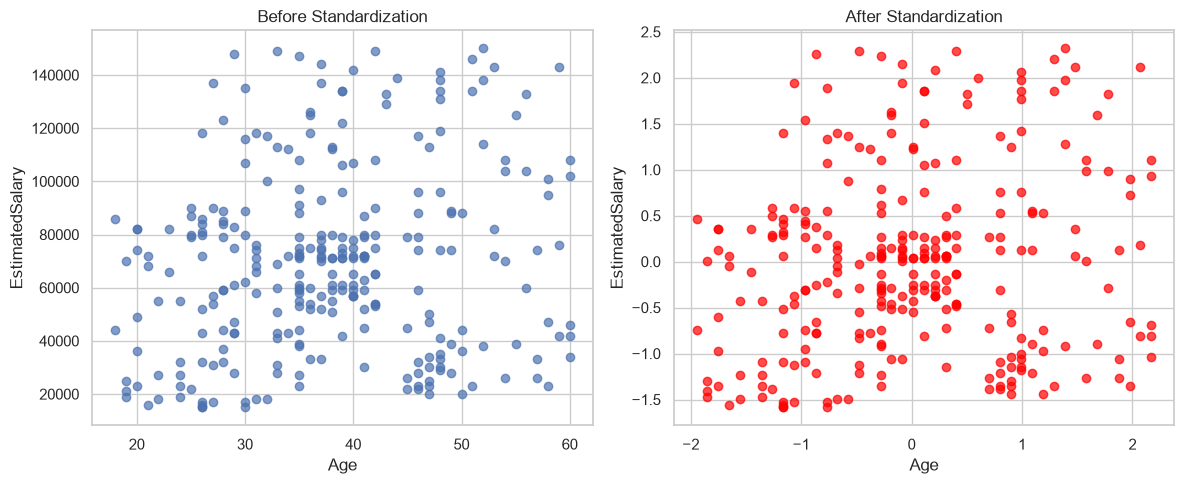

In [53]:
# Visual comparison: standardization changes scale, not the relative pattern of points.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(X_train_ads["Age"], X_train_ads["EstimatedSalary"], alpha=0.7)
ax1.set_title("Before Standardization")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")

ax2.scatter(X_train_standard_df["Age"], X_train_standard_df["EstimatedSalary"], color="red", alpha=0.7)
ax2.set_title("After Standardization")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")
plt.tight_layout()
plt.show()

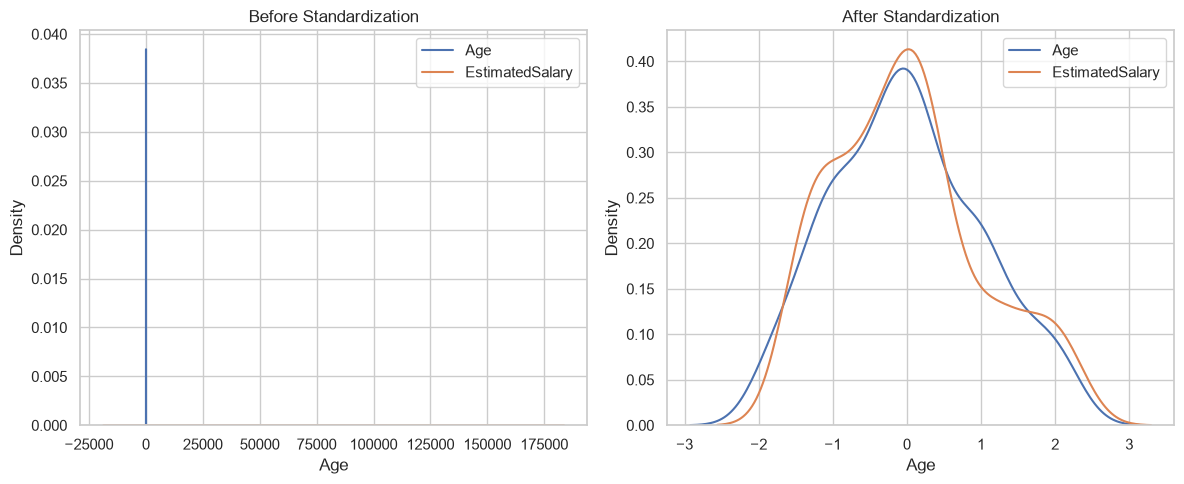

In [54]:
# Distribution comparison: the curves move to a shared standardized scale.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.set_title("Before Standardization")
sns.kdeplot(X_train_ads["Age"], ax=ax1, label="Age")
sns.kdeplot(X_train_ads["EstimatedSalary"], ax=ax1, label="EstimatedSalary")
ax1.legend()

ax2.set_title("After Standardization")
sns.kdeplot(X_train_standard_df["Age"], ax=ax2, label="Age")
sns.kdeplot(X_train_standard_df["EstimatedSalary"], ax=ax2, label="EstimatedSalary")
ax2.legend()
plt.tight_layout()
plt.show()

### Normalization with Min-Max Scaling

Normalization, or Min-Max scaling, rescales values into a fixed range, usually
0 to 1. It is useful for algorithms that depend on distances or bounded inputs.

In [72]:
# Load the wine dataset used for normalization.
wine_data_url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch06/wine.csv'

wine_df = pd.read_csv(wine_data_url)

print(wine_df[["Wine", "Alcohol", "Malic.acid"]].head())

   Wine  Alcohol  Malic.acid
0     1    14.23        1.71
1     1    13.20        1.78
2     1    13.16        2.36
3     1    14.37        1.95
4     1    13.24        2.59


In [75]:
print("\nOriginal selected feature ranges:")
print(wine_df[["Alcohol", "Malic.acid"]].agg(["min", "max", "mean", "std"]).round(2))


Original selected feature ranges:
      Alcohol  Malic.acid
min     11.03        0.74
max     14.83        5.80
mean    13.00        2.34
std      0.81        1.12


In [74]:
# Split before scaling, then fit MinMaxScaler only on the training set.
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    wine_df.drop("Wine", axis=1),
    wine_df["Wine"],
    test_size=0.3,
    random_state=0,
)

# Before: inspect two columns with different ranges.
print(X_train_wine[["Alcohol", "Malic.acid"]].head())

     Alcohol  Malic.acid
22     13.71        1.86
108    12.22        1.29
175    13.27        4.28
145    13.16        3.57
71     13.86        1.51


In [57]:
# Apply Min-Max scaling.
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(X_train_wine)

X_train_minmax = minmax_scaler.transform(X_train_wine)
X_test_minmax = minmax_scaler.transform(X_test_wine)

X_train_minmax_df = pd.DataFrame(X_train_minmax, columns=X_train_wine.columns, index=X_train_wine.index)
X_test_minmax_df = pd.DataFrame(X_test_minmax, columns=X_test_wine.columns, index=X_test_wine.index)

# After: training values now sit between 0 and 1 for every feature.
print(X_train_minmax_df[["Alcohol", "Malic.acid"]].head())
print("\nScaled training ranges:")
print(X_train_minmax_df[["Alcohol", "Malic.acid"]].agg(["min", "max"]).round(3))

      Alcohol  Malic.acid
22   0.720430    0.203782
108  0.319892    0.084034
175  0.602151    0.712185
145  0.572581    0.563025
71   0.760753    0.130252

Scaled training ranges:
     Alcohol  Malic.acid
min      0.0         0.0
max      1.0         1.0


The above output shows that both columns `Alcohol` and `Malic.acid` have been scaled to a new range having 0 as minimum value and 1 as maximum value

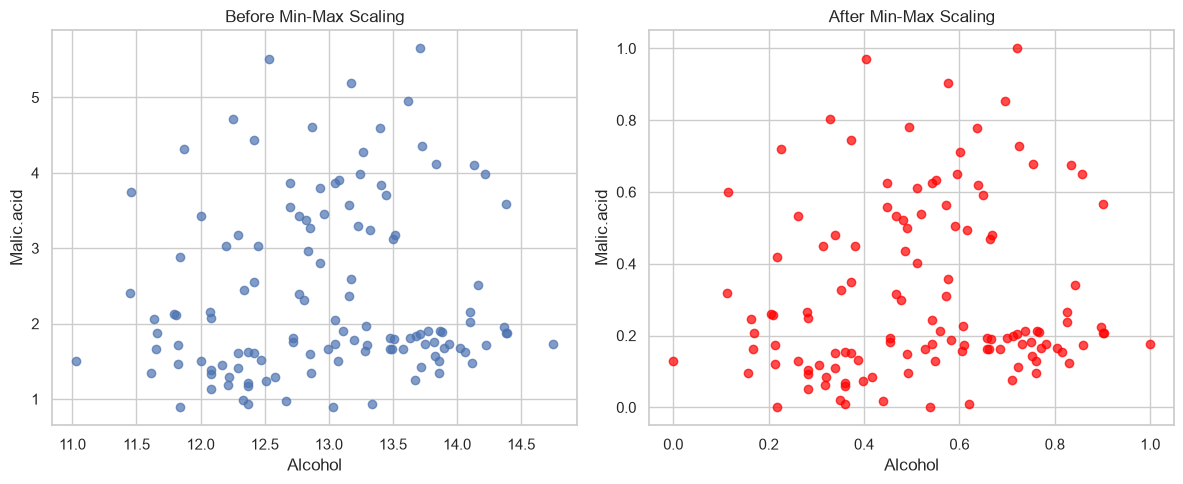

In [58]:
# Visual comparison for two wine features.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(X_train_wine["Alcohol"], X_train_wine["Malic.acid"], alpha=0.7)
ax1.set_title("Before Min-Max Scaling")
ax1.set_xlabel("Alcohol")
ax1.set_ylabel("Malic.acid")

ax2.scatter(X_train_minmax_df["Alcohol"], X_train_minmax_df["Malic.acid"], color="red", alpha=0.7)
ax2.set_title("After Min-Max Scaling")
ax2.set_xlabel("Alcohol")
ax2.set_ylabel("Malic.acid")
plt.tight_layout()
plt.show()

The above output shows that - min max scaling only changes the scale of data but has no effect on the relative patterns of the data

   original  minmax_scaled
0        10       0.000000
1        15       0.055556
2        20       0.111111
3        25       0.166667
4        30       0.222222
5       100       1.000000


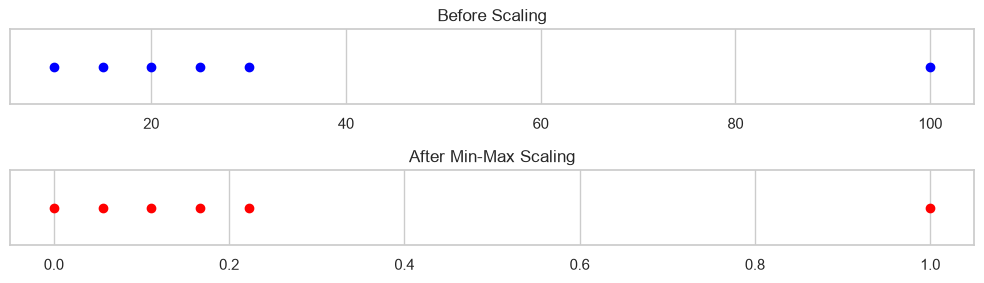

In [59]:
# Outlier demonstration from the chapter: Min-Max scaling keeps the outlier at 1
# and squeezes the remaining values into a smaller part of the 0-to-1 range.
x = np.array([10, 15, 20, 25, 30, 100])
x_scaled = MinMaxScaler().fit_transform(x.reshape(-1, 1)).ravel()

outlier_demo = pd.DataFrame({"original": x, "minmax_scaled": x_scaled})
print(outlier_demo)

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 3), sharey=True)
ax1.scatter(x, np.zeros_like(x), color="blue")
ax1.set_title("Before Scaling")
ax1.set_yticks([])

ax2.scatter(x_scaled, np.zeros_like(x_scaled), color="red")
ax2.set_title("After Min-Max Scaling")
ax2.set_yticks([])
plt.tight_layout()
plt.show()

### Standardization vs. Normalization

Use standardization when algorithms benefit from centered data, such as linear
models, SVMs, PCA, and many gradient-based methods. 

Use normalization when a fixed positive range is helpful, such as for distance-based methods, clustering,
image-like bounded inputs, or neural-network workflows.

In practice, try the scaling method that matches the model and data, then verify
model performance instead of assuming one method is always best.

## Feature Transformation

Feature transformation changes the distribution of numerical features. This is
useful when data is skewed, has long tails, or contains values whose relationship
with the target is easier to model after a mathematical transformation.

This chapter covers log transformation, square root transformation, square
transformation, and Box-Cox transformation.

### Log, Square Root, and Square Transformations

Log transformation compresses large positive values and is useful for strong
right skew.

Square root transformation is gentler and works well for moderate
right skew. 

Square transformation magnifies larger values and can help with some
left-skewed features.

In [60]:
# Small numeric example to make the transformations visible before using a dataset.
example_values = pd.DataFrame({"value": [1, 4, 9, 16, 25, 100]})
example_values["log1p"] = np.log1p(example_values["value"])
example_values["sqrt"] = np.sqrt(example_values["value"])
example_values["square"] = np.square(example_values["value"])
print(example_values)

   value     log1p  sqrt  square
0      1  0.693147   1.0       1
1      4  1.609438   2.0      16
2      9  2.302585   3.0      81
3     16  2.833213   4.0     256
4     25  3.258097   5.0     625
5    100  4.615121  10.0   10000


### Applying Transformations to the Boston Housing Dataset

Let's applytransformations to three features of the Boston Housing data: CRIM, LSTAT, and AGE. 

MEDV is the regression target here.

In [83]:
# Load the Boston Housing data and keep the columns used in the chapter.
housing_data_url = url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch06/BostonHousing.csv'

boston_df = pd.read_csv(housing_data_url)

boston_df = boston_df[["CRIM", "LSTAT", "AGE", "MEDV"]]

print(boston_df.head())

      CRIM  LSTAT   AGE  MEDV
0  0.00632   4.98  65.2  24.0
1  0.02731   9.14  78.9  21.6
2  0.02729   4.03  61.1  34.7
3  0.03237   2.94  45.8  33.4
4  0.06905   5.33  54.2  36.2


Skewness before transformation:
CRIM     5.223
LSTAT    0.906
AGE     -0.599
dtype: float64


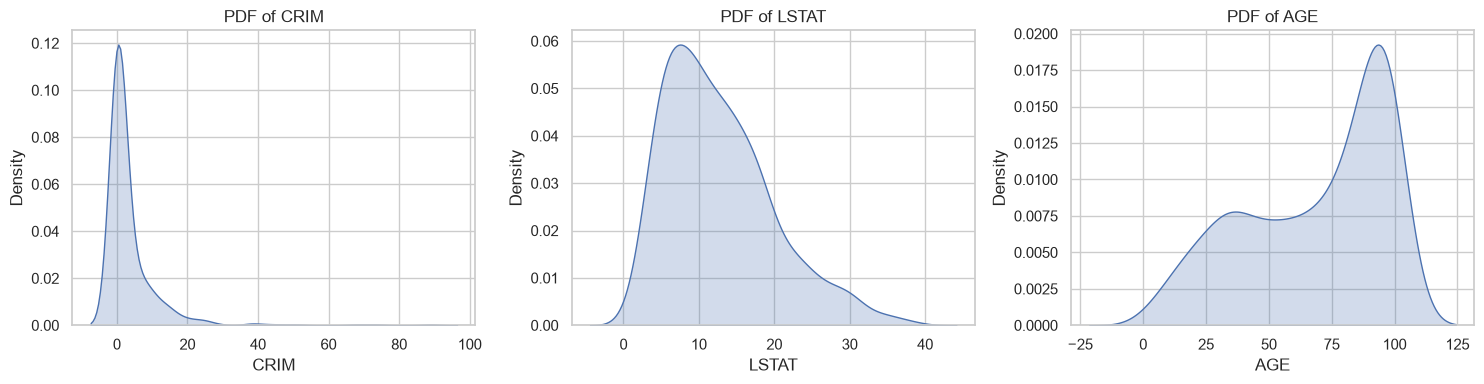

In [84]:
# Before: inspect distribution skewness for the feature columns.
feature_cols = ["CRIM", "LSTAT", "AGE"]
print("Skewness before transformation:")
print(boston_df[feature_cols].skew().round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, feature_cols):
    sns.kdeplot(boston_df[col], ax=ax, fill=True)
    ax.set_title(f"PDF of {col}")
plt.tight_layout()
plt.show()

In [85]:
# Split the data before applying transformations so model evaluation stays honest.
X_train_boston, X_test_boston, y_train_boston, y_test_boston = train_test_split(
    boston_df[feature_cols],
    boston_df["MEDV"],
    test_size=0.3,
    random_state=42,
)
print(X_train_boston.head())

         CRIM  LSTAT   AGE
5     0.02985   5.21  58.7
116   0.13158  12.04  72.5
45    0.17142  10.21  33.8
16    1.05393   6.58  29.3
468  15.57570  18.13  71.0


In [86]:
# Apply the chapter's chosen transformations.
X_train_transformed = X_train_boston.copy()
X_test_transformed = X_test_boston.copy()

X_train_transformed["CRIM"] = np.log1p(X_train_boston["CRIM"])
X_train_transformed["LSTAT"] = np.sqrt(X_train_boston["LSTAT"])
X_train_transformed["AGE"] = np.square(X_train_boston["AGE"])

X_test_transformed["CRIM"] = np.log1p(X_test_boston["CRIM"])
X_test_transformed["LSTAT"] = np.sqrt(X_test_boston["LSTAT"])
X_test_transformed["AGE"] = np.square(X_test_boston["AGE"])

# After: compare skewness before and after transformation.
skew_compare = pd.DataFrame({"before": X_train_boston.skew(), "after": X_train_transformed.skew()}).round(3)
print(skew_compare)

       before  after
CRIM    5.654  1.270
LSTAT   0.969  0.344
AGE    -0.618 -0.180


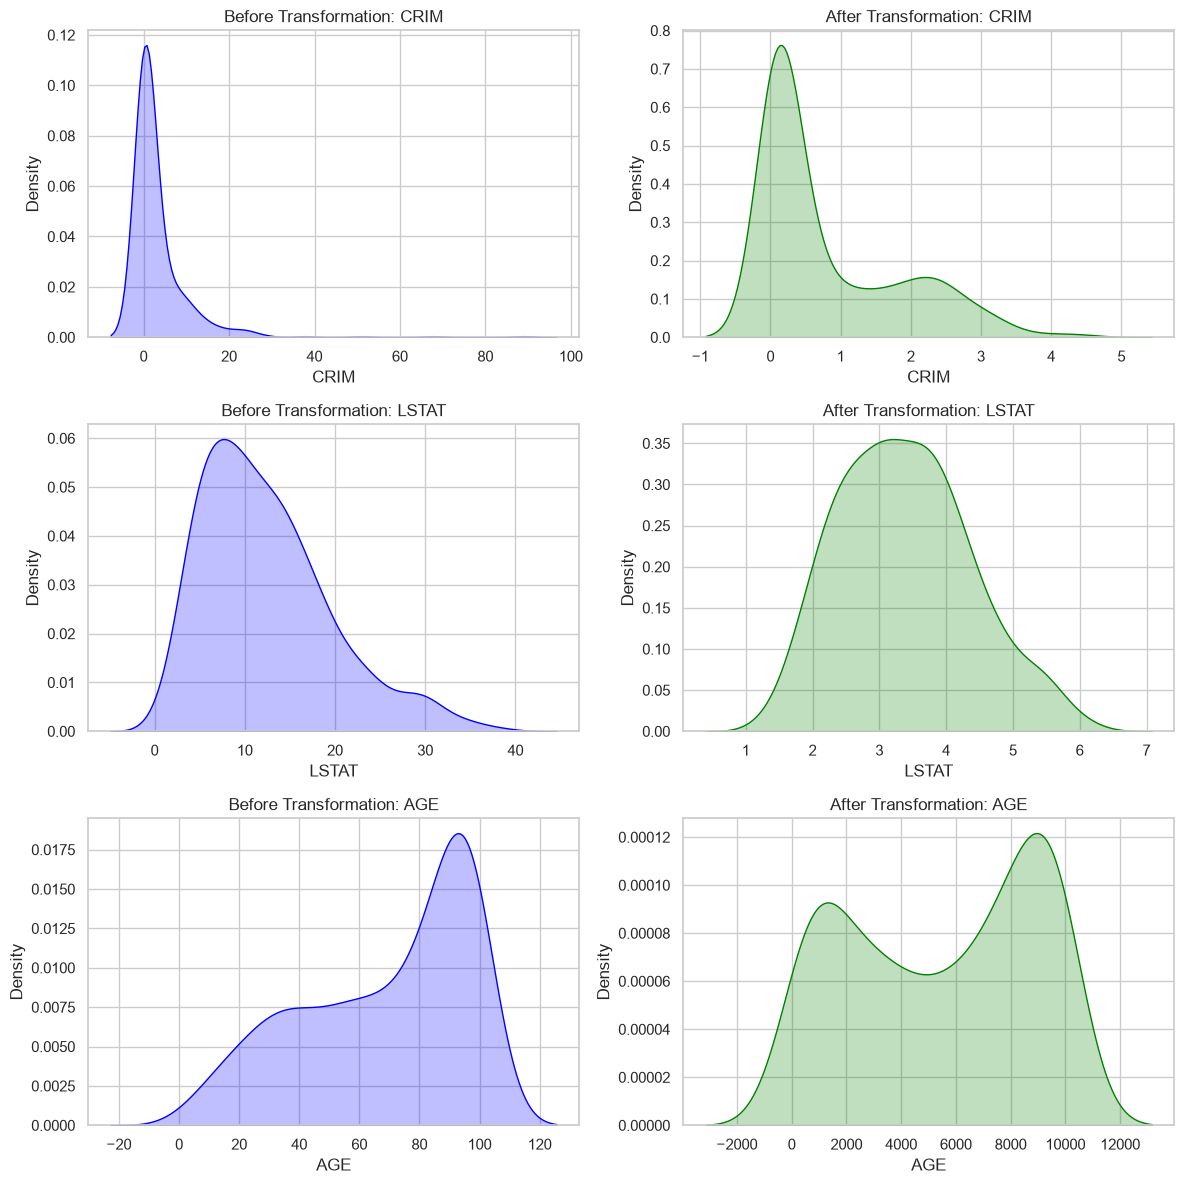

In [87]:
# Visual before/after comparison for each transformed feature.
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for row, col in enumerate(feature_cols):
    sns.kdeplot(X_train_boston[col], ax=axes[row, 0], fill=True, color="blue")
    axes[row, 0].set_title(f"Before Transformation: {col}")

    sns.kdeplot(X_train_transformed[col], ax=axes[row, 1], fill=True, color="green")
    axes[row, 1].set_title(f"After Transformation: {col}")
plt.tight_layout()
plt.show()

In [89]:
# Metrics of model trained on data on which no transformations are applied
linear_model_original = LinearRegression()
linear_model_original.fit(X_train_boston, y_train_boston)
y_pred_original = linear_model_original.predict(X_test_boston)

print("Original data model")
print("R2_score (greater is better):", round(r2_score(y_test_boston, y_pred_original), 4))
print("Mean Squared Error (lower is better):", round(mean_squared_error(y_test_boston, y_pred_original), 4))

Original data model
R2_score (greater is better): 0.492
Mean Squared Error (lower is better): 37.852


In [ ]:
# Metrics of model trained on data on which transformations are applied
linear_model_transformed = LinearRegression()
linear_model_transformed.fit(X_train_transformed, y_train_boston)
y_pred_transformed = linear_model_transformed.predict(X_test_transformed)

print("Transformed data model")
print("R2_score (greater is better):", round(r2_score(y_test_boston, y_pred_transformed), 4))
print("Mean Squared Error (lower is better):", round(mean_squared_error(y_test_boston, y_pred_transformed), 4))

Transformed data model
R2_score (greater is better): 0.5898
Mean Squared Error (lower is better): 30.5677


It is clear from above output that - transformations really help us in improving the metrics of our ML model

### Box-Cox Transformation

Box-Cox is a power transformation that automatically chooses a lambda value for
each feature. It can behave like log, square root, or other power transforms
depending on the learned lambda. Box-Cox requires positive input values, so a
small constant is added here before fitting.

In [93]:
# Apply Box-Cox transformation to the same feature set.
boxcox_transformer = PowerTransformer(method="box-cox")

X_train_boxcox = boxcox_transformer.fit_transform(X_train_boston + 0.000001)
X_test_boxcox = boxcox_transformer.transform(X_test_boston + 0.000001)

boxcox_lambdas = pd.DataFrame({"feature": X_train_boston.columns, "box_cox_lambda": boxcox_transformer.lambdas_})

print(boxcox_lambdas.round(4))

  feature  box_cox_lambda
0    CRIM         -0.1160
1   LSTAT          0.2169
2     AGE          1.3713


In [94]:
# Verify how Box-Cox changed skewness on the training data.
X_train_boxcox_df = pd.DataFrame(X_train_boxcox, columns=feature_cols, index=X_train_boston.index)
boxcox_skew_compare = pd.DataFrame({"before": X_train_boston.skew(), "after_boxcox": X_train_boxcox_df.skew()}).round(3)
print(boxcox_skew_compare)

       before  after_boxcox
CRIM    5.654         0.096
LSTAT   0.969        -0.024
AGE    -0.618        -0.421


It is clear from the above output that Box-Cox transformation has adjusted each feature to reduce skewness and bring their distributions closer to normal by finding a lambda for each of the features.

## Chapter Wrap-Up

In this chapter we prepared features in three ways.

- Encoding converted categories into numbers,
- scaling brought numerical columns onto comparable ranges, and
- transformations reshaped skewed features. 

These steps do not replace model evaluation; they make the data more suitable for learning, and we still verify
the effect with summaries, plots, and model metrics.